# Campus Traffic Flow Field
Prototype visualization of the normalized movement flow vector per WAP node for the peak 1-hour traffic window.

In [1]:
import sys, os, re
from pathlib import Path
from collections import defaultdict
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from pipeline.run_logic.ast_runner import load_step_module
phase_dir = Path(project_root) / 'pipeline' / 'phases' / 'phase_01_build_world--Lucas_Starkey'
load_step_module(phase_dir, phase_dir / 'steps' / 'step_01_build_devices.py')
load_step_module(phase_dir, phase_dir / 'steps' / 'step_03_resolve_people.py')
load_step_module(phase_dir, phase_dir / 'steps' / 'step_04_build_graph.py')
load_step_module(phase_dir, phase_dir / 'steps' / 'step_05_build_journeys.py')
load_step_module(phase_dir, phase_dir / 'steps' / 'step_06_interpolate_paths.py')

from pipelineio.state import load_draft

run_id = os.environ.get('PIPELINE_RUN_ID', 'EXAMPLE_RUN_ID')
graph = load_draft(f'../data/artifacts/runs/{run_id}/world/final_graph.pkl')
journeys = load_draft(f'../data/artifacts/runs/{run_id}/world/final_journeys.pkl')

print(f'Graph Nodes: {len(graph.nodes)}')
print(f'Journeys: {len(journeys.journeys)}')

Graph Nodes: 25
Journeys: 112755


In [2]:
# --- Parse WAP coordinates from SVG edge paths ---
# Each <path id="WAP1__WAP2" d="M x1 y1 C..." .../> encodes the start pos of WAP1
svg_path = Path(project_root) / 'data' / 'raw' / 'synthetic' / 'export route.svg'
content = svg_path.read_text(encoding='utf-8')

# Extract all paths: (id, start_x, start_y)
path_pattern = re.compile(r'id="([^"]+)__([^"]+)"[^d]*d="M([\d.]+)\s+([\d.]+)')
wap_coords = {}  # wap_id -> (x, y)

for m in path_pattern.finditer(content):
    w1, w2, x, y = m.group(1), m.group(2), float(m.group(3)), float(m.group(4))
    if w1 not in wap_coords:
        wap_coords[w1] = (x, y)

print(f'Resolved coordinates for {len(wap_coords)} WAPs')
print('Sample:', list(wap_coords.items())[:3]) 

Resolved coordinates for 25 WAPs
Sample: [('AIEB-RMC353', (89.1135, 84.24)), ('AIEB-RM354-3', (85.4104, 127.36)), ('AIEB-RM244-1', (67.8616, 169.12))]


In [3]:
# --- Bin all journey transitions by 1-hour window ---
# Structure: hour_bin (int, e.g. 10 = 10:00-11:00) -> {wap_id -> [(dx, dy)]}
hour_vectors = defaultdict(lambda: defaultdict(list))  # bin -> wap -> [(dx, dy)]
hour_volume  = defaultdict(lambda: defaultdict(set))   # bin -> wap -> set of person_ids

SKIP_LARGE_GAP_MS = 30 * 60 * 1000  # 30 min

for journey in journeys.journeys:
    for i in range(len(journey.waypoints) - 1):
        wp      = journey.waypoints[i]
        next_wp = journey.waypoints[i + 1]

        if wp.wap_id == next_wp.wap_id:
            continue

        # Only include WAPs we have coordinates for
        if wp.wap_id not in wap_coords or next_wp.wap_id not in wap_coords:
            continue

        dt        = datetime.fromtimestamp(wp.timestamp / 1000.0)
        hour_bin  = dt.hour

        ox, oy = wap_coords[wp.wap_id]
        dx, dy = wap_coords[next_wp.wap_id]

        # Direction vector from origin to destination
        vec = (dx - ox, dy - oy)

        hour_vectors[hour_bin][wp.wap_id].append(vec)
        hour_volume[hour_bin][wp.wap_id].add(journey.person_id)

# Find the peak hour
total_per_hour = {h: sum(len(vs) for vs in waps.values()) for h, waps in hour_vectors.items()}
peak_hour = max(total_per_hour, key=total_per_hour.get)

print('Transitions per hour:', dict(sorted(total_per_hour.items())))
print(f'\nPeak hour: {peak_hour}:00 - {peak_hour+1}:00  ({total_per_hour[peak_hour]} transitions)')

Transitions per hour: {0: 118, 1: 82, 2: 53, 3: 20, 4: 8, 5: 12, 6: 65, 7: 1800, 8: 4833, 9: 6169, 10: 4893, 11: 4746, 12: 4277, 13: 3433, 14: 4283, 15: 2512, 16: 2133, 17: 1801, 18: 1438, 19: 1070, 20: 724, 21: 470, 22: 328, 23: 273}

Peak hour: 9:00 - 10:00  (6169 transitions)


In [4]:
# --- Build the flow field arrays for the peak hour ---
wap_data = hour_vectors[peak_hour]
vol_data  = hour_volume[peak_hour]

xs, ys, us, vs_arr, volumes = [], [], [], [], []

for wap_id, vecs in wap_data.items():
    if wap_id not in wap_coords:
        continue

    ox, oy = wap_coords[wap_id]

    # Sum all direction vectors
    sx = sum(v[0] for v in vecs)
    sy = sum(v[1] for v in vecs)
    mag = (sx**2 + sy**2) ** 0.5

    if mag == 0:
        continue

    # Normalize
    nx_val, ny_val = sx / mag, sy / mag

    xs.append(ox)
    ys.append(oy)
    us.append(nx_val)
    vs_arr.append(ny_val)
    volumes.append(len(vol_data[wap_id]))

xs       = np.array(xs)
ys       = np.array(ys)
us       = np.array(us)
vs_arr   = np.array(vs_arr)
volumes  = np.array(volumes, dtype=float)

print(f'{len(xs)} WAPs have flow vectors in the peak hour')

25 WAPs have flow vectors in the peak hour


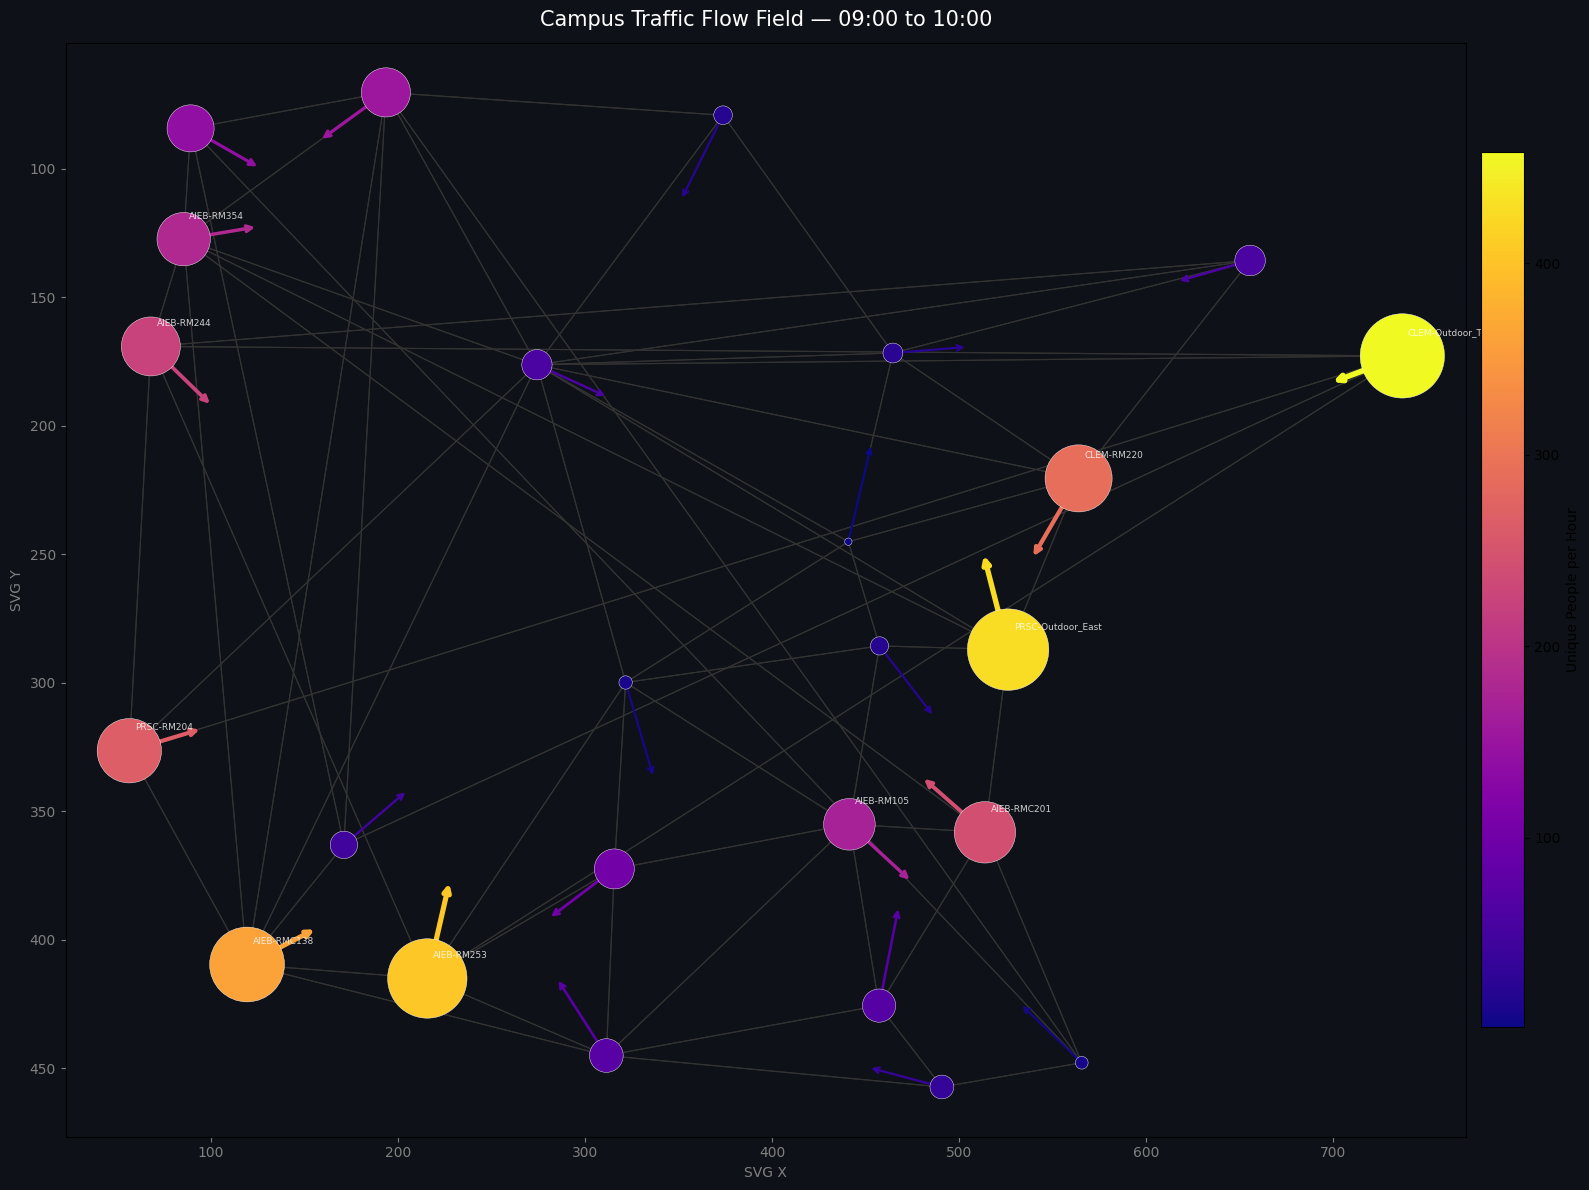

Flow field rendered for 25 WAPs in the 9:00 hour


In [5]:
# --- Render the quiver / flow field ---
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor('#0e1117')
fig.patch.set_facecolor('#0e1117')

# Draw the underlying graph edges as dim grey lines for context
for w1, neighbors in graph.physical_edges.items():
    if w1 not in wap_coords:
        continue
    for w2 in neighbors:
        if w2 not in wap_coords:
            continue
        x1, y1 = wap_coords[w1]
        x2, y2 = wap_coords[w2]
        ax.plot([x1, x2], [y1, y2], color='#333333', linewidth=0.8, zorder=1)

# Color map based on people volume
norm   = mcolors.Normalize(vmin=volumes.min(), vmax=volumes.max())
cmap   = cm.plasma
colors = cmap(norm(volumes))

# Arrow scale: fixed length (normalized), scaled visually
scale = 40
for i in range(len(xs)):
    ax.annotate(
        '',
        xy=(xs[i] + us[i] * scale, ys[i] + vs_arr[i] * scale),
        xytext=(xs[i], ys[i]),
        arrowprops=dict(
            arrowstyle='->', color=colors[i],
            lw=1.5 + norm(volumes[i]) * 2.5
        ),
        zorder=3
    )

# Node scatter (size = volume)
scatter = ax.scatter(
    xs, ys, c=volumes, cmap='plasma', s=20 + volumes * 8,
    norm=norm, edgecolors='white', linewidths=0.3, zorder=4
)

# Label top 10 busiest nodes
top_idx = np.argsort(volumes)[-10:]
for i in top_idx:
    wap_id = list(wap_data.keys())[i]
    ax.text(xs[i] + 3, ys[i] - 8, wap_id.split('-')[0] + '-' + (wap_id.split('-')[1] if len(wap_id.split('-')) > 1 else ''),
            color='white', fontsize=6.5, zorder=5, alpha=0.8)

plt.colorbar(scatter, ax=ax, label='Unique People per Hour', fraction=0.03, pad=0.01)

ax.set_title(
    f'Campus Traffic Flow Field — {peak_hour:02d}:00 to {(peak_hour+1)%24:02d}:00',
    color='white', fontsize=15, pad=12
)
ax.tick_params(colors='grey')
ax.set_xlabel('SVG X', color='grey')
ax.set_ylabel('SVG Y', color='grey')
ax.invert_yaxis()  # SVG y-axis is top-down
plt.tight_layout()
plt.show()
print(f'Flow field rendered for {len(xs)} WAPs in the {peak_hour}:00 hour')

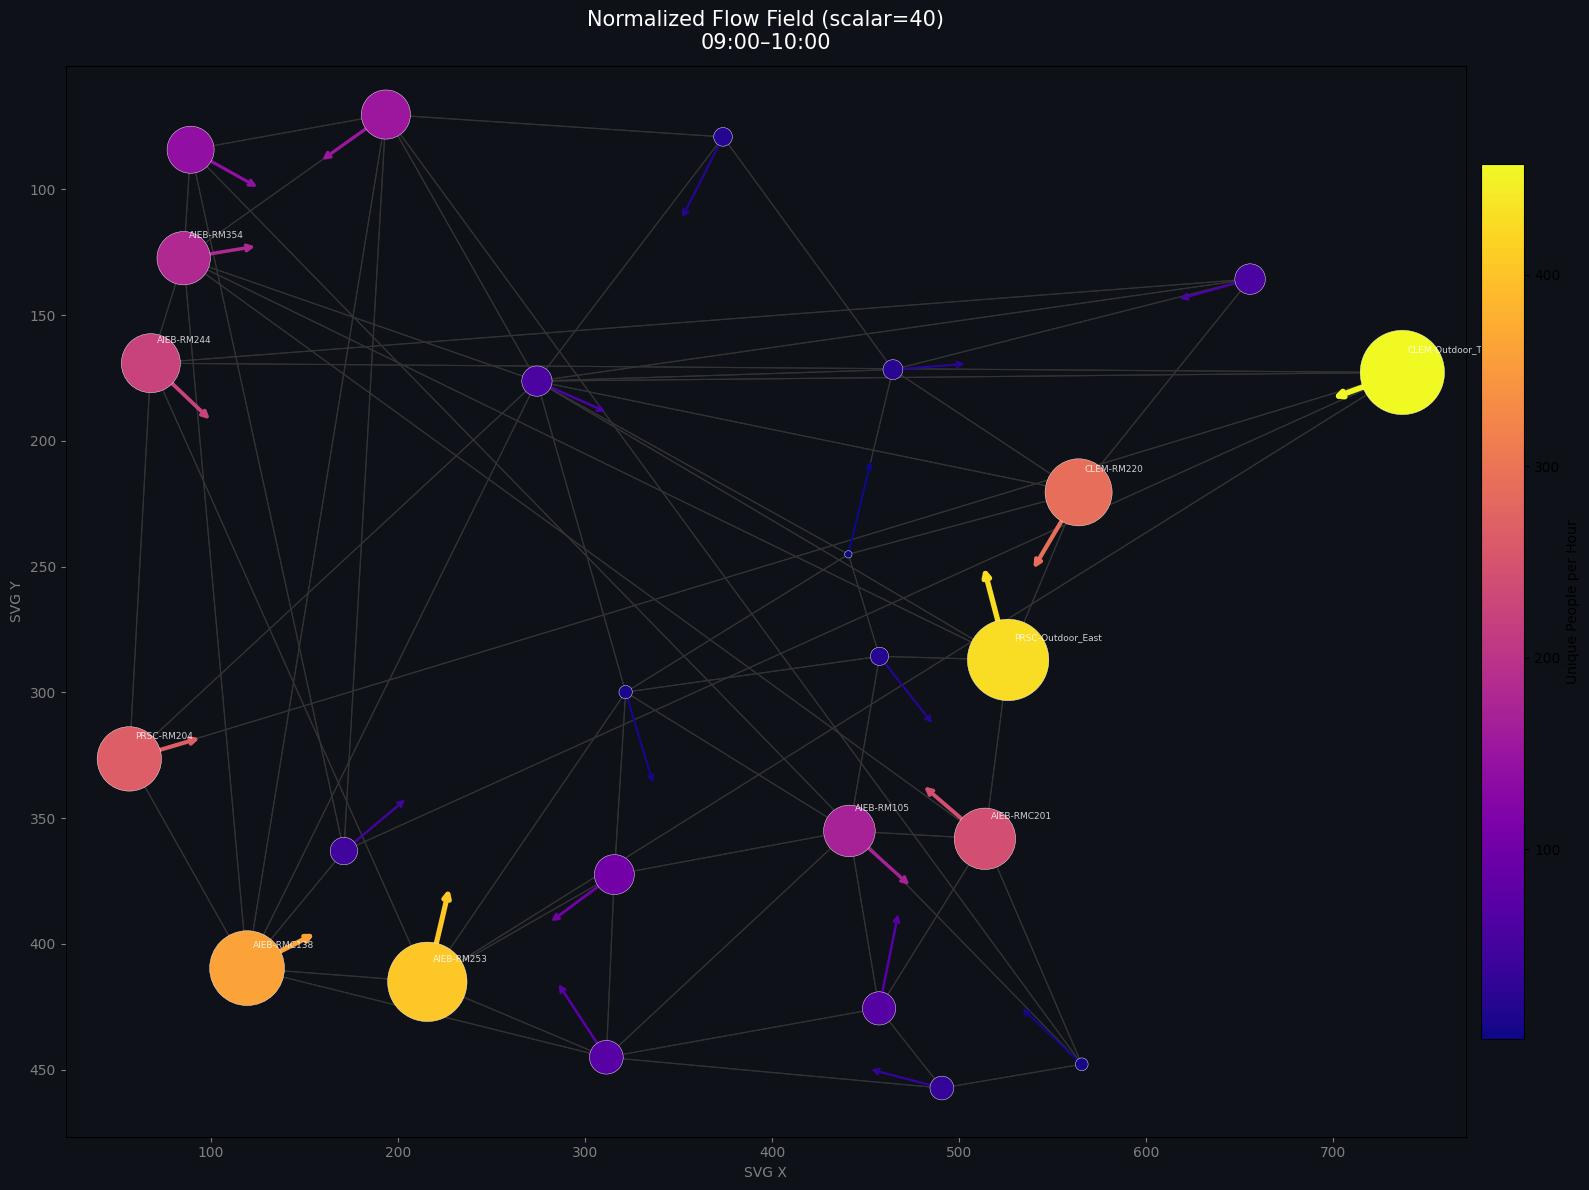

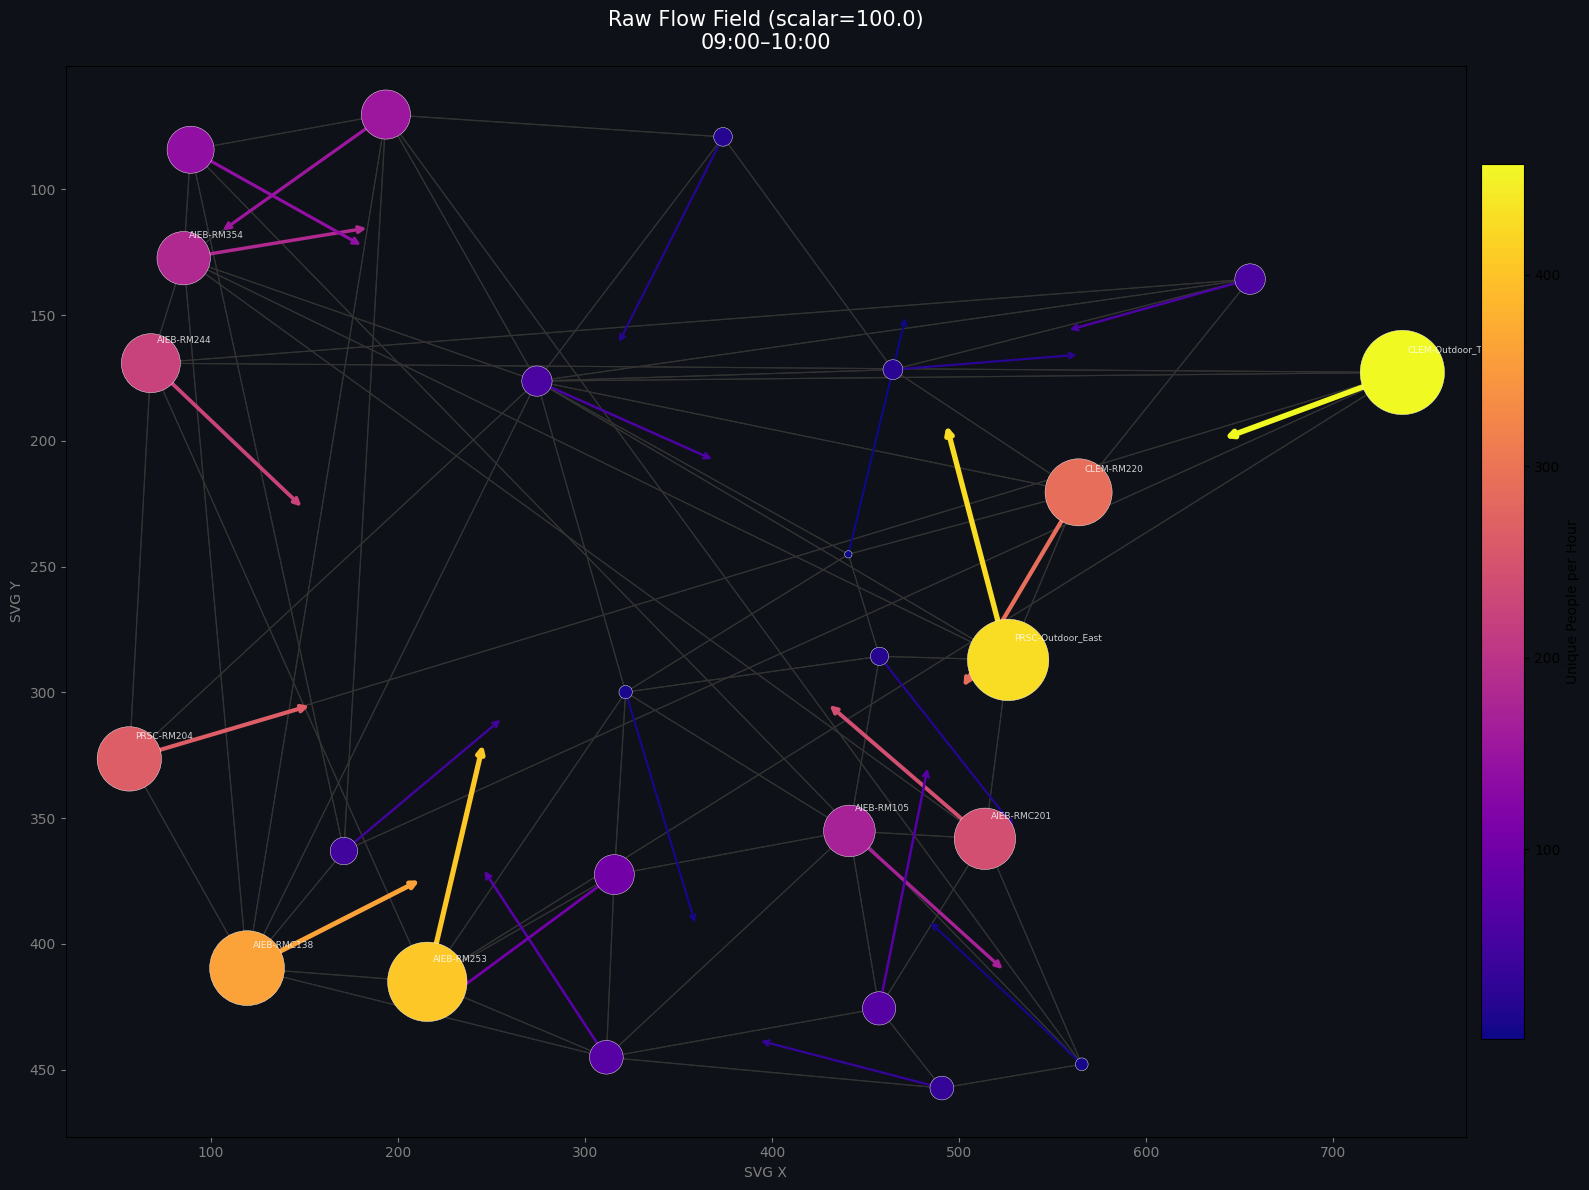

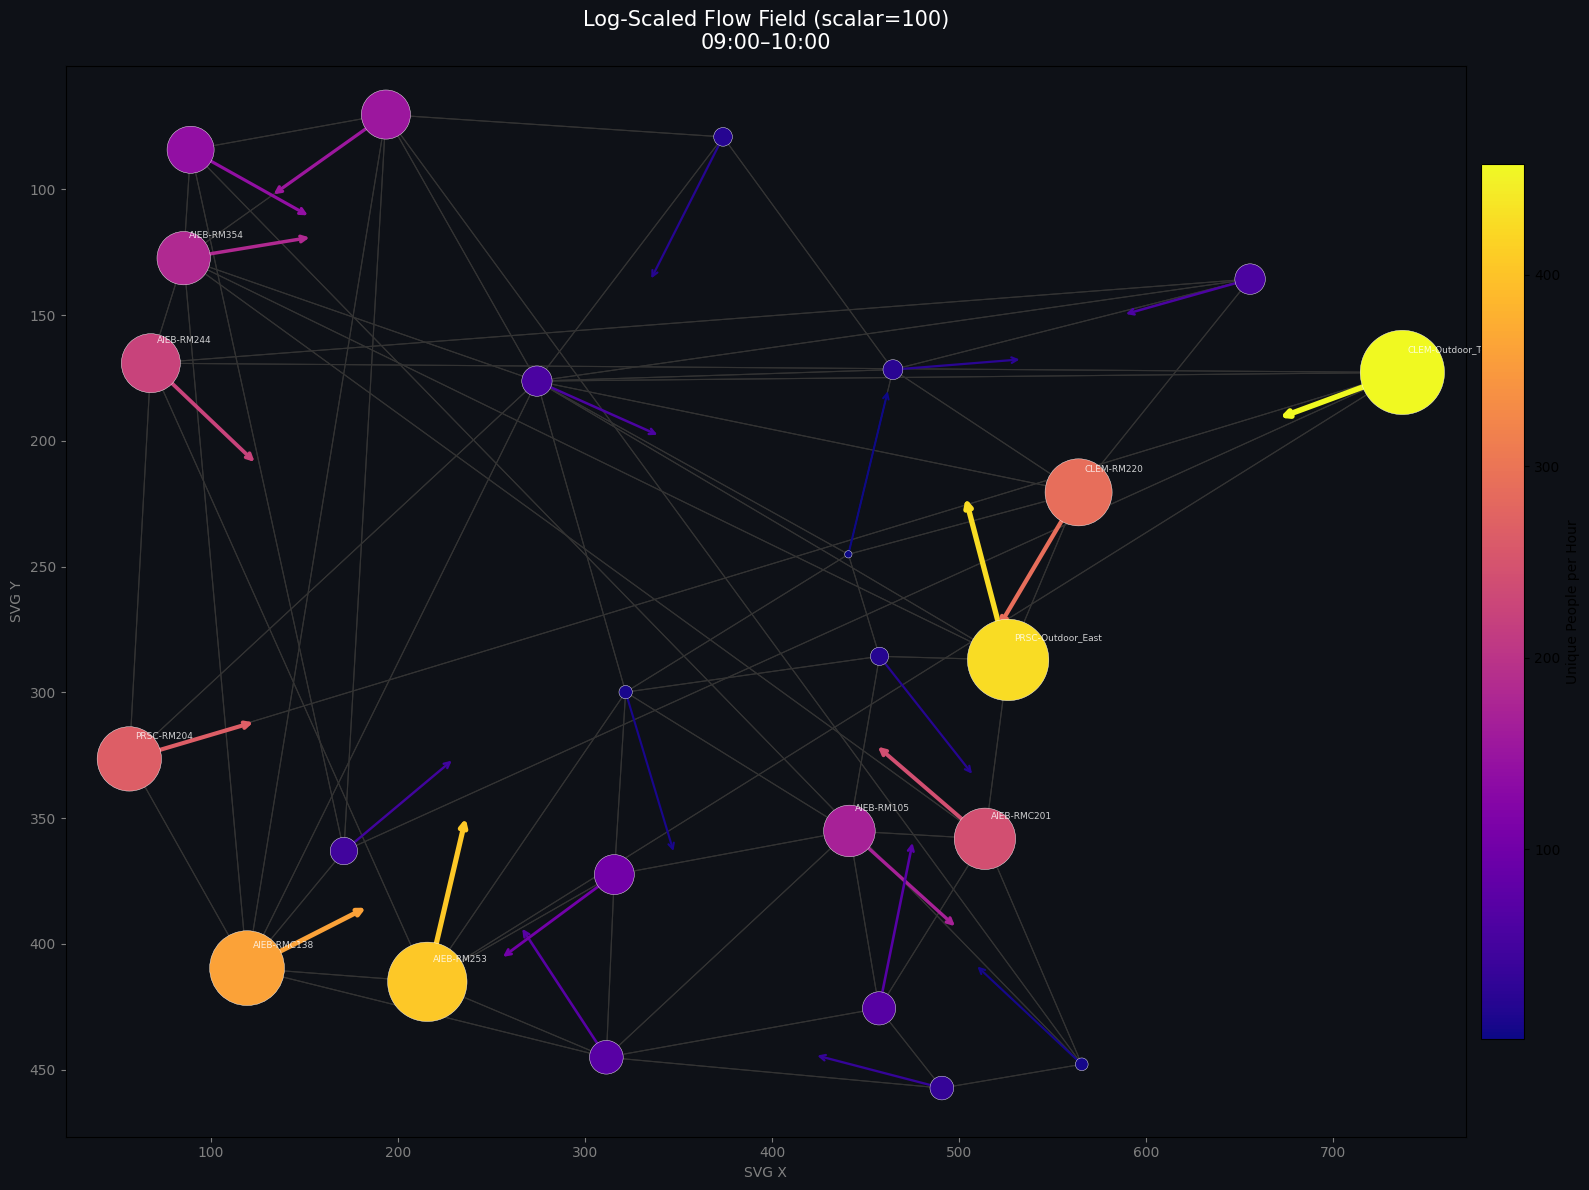

Rendered 3 flow field views for 25 WAPs at hour 9


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


# =========================================================
# TWEAKABLE VISIBILITY SCALARS
# =========================================================
NORMALIZED_SCALE = 40
RAW_SCALE = 100.0
LOG_SCALE = 100

TOP_N_LABELS = 10


# =========================================================
# HELPERS
# =========================================================
def safe_normalize(u, v):
    mag = np.sqrt(u**2 + v**2)
    mag_safe = np.where(mag == 0, 1.0, mag)
    return u / mag_safe, v / mag_safe, mag

def log_scale_vectors(u, v):
    mag = np.sqrt(u**2 + v**2)
    mag_safe = np.where(mag == 0, 1.0, mag)
    log_mag = np.log1p(mag)
    return (u / mag_safe) * log_mag, (v / mag_safe) * log_mag, mag

def short_wap_label(wap_id):
    parts = wap_id.split('-')
    return parts[0] + '-' + (parts[1] if len(parts) > 1 else '')

def draw_base(ax, graph, wap_coords):
    ax.set_facecolor('#0e1117')

    for w1, neighbors in graph.physical_edges.items():
        if w1 not in wap_coords:
            continue
        for w2 in neighbors:
            if w2 not in wap_coords:
                continue
            x1, y1 = wap_coords[w1]
            x2, y2 = wap_coords[w2]
            ax.plot([x1, x2], [y1, y2], color='#333333', linewidth=0.8, zorder=1)

def render_single(
    title,
    xs, ys,
    u_plot, v_plot,
    volumes,
    wap_ids,
    graph,
    wap_coords,
    scalar
):
    fig, ax = plt.subplots(figsize=(16, 12))
    fig.patch.set_facecolor('#0e1117')

    draw_base(ax, graph, wap_coords)

    norm = mcolors.Normalize(vmin=volumes.min(), vmax=volumes.max())
    cmap = cm.plasma
    colors = cmap(norm(volumes))

    # arrows
    for i in range(len(xs)):
        dx = u_plot[i] * scalar
        dy = v_plot[i] * scalar

        ax.annotate(
            '',
            xy=(xs[i] + dx, ys[i] + dy),
            xytext=(xs[i], ys[i]),
            arrowprops=dict(
                arrowstyle='->',
                color=colors[i],
                lw=1.5 + norm(volumes[i]) * 2.5
            ),
            zorder=3
        )

    # nodes
    scatter = ax.scatter(
        xs, ys,
        c=volumes,
        cmap='plasma',
        s=20 + volumes * 8,
        norm=norm,
        edgecolors='white',
        linewidths=0.3,
        zorder=4
    )

    # labels
    top_idx = np.argsort(volumes)[-TOP_N_LABELS:]
    for i in top_idx:
        ax.text(
            xs[i] + 3,
            ys[i] - 8,
            short_wap_label(wap_ids[i]),
            color='white',
            fontsize=6.5,
            zorder=5,
            alpha=0.8
        )

    plt.colorbar(scatter, ax=ax, label='Unique People per Hour', fraction=0.03, pad=0.01)

    ax.set_title(title, color='white', fontsize=15, pad=12)
    ax.tick_params(colors='grey')
    ax.set_xlabel('SVG X', color='grey')
    ax.set_ylabel('SVG Y', color='grey')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


# =========================================================
# PREP
# =========================================================
wap_ids = list(wap_data.keys())

u_norm, v_norm, _ = safe_normalize(us, vs_arr)
u_raw, v_raw = us.copy(), vs_arr.copy()
u_log, v_log, _ = log_scale_vectors(us, vs_arr)


# =========================================================
# RENDER (3 SEPARATE FIGURES)
# =========================================================

render_single(
    title=f'Normalized Flow Field (scalar={NORMALIZED_SCALE})\n{peak_hour:02d}:00–{(peak_hour+1)%24:02d}:00',
    xs=xs, ys=ys,
    u_plot=u_norm, v_plot=v_norm,
    volumes=volumes,
    wap_ids=wap_ids,
    graph=graph,
    wap_coords=wap_coords,
    scalar=NORMALIZED_SCALE
)

render_single(
    title=f'Raw Flow Field (scalar={RAW_SCALE})\n{peak_hour:02d}:00–{(peak_hour+1)%24:02d}:00',
    xs=xs, ys=ys,
    u_plot=u_raw, v_plot=v_raw,
    volumes=volumes,
    wap_ids=wap_ids,
    graph=graph,
    wap_coords=wap_coords,
    scalar=RAW_SCALE
)

render_single(
    title=f'Log-Scaled Flow Field (scalar={LOG_SCALE})\n{peak_hour:02d}:00–{(peak_hour+1)%24:02d}:00',
    xs=xs, ys=ys,
    u_plot=u_log, v_plot=v_log,
    volumes=volumes,
    wap_ids=wap_ids,
    graph=graph,
    wap_coords=wap_coords,
    scalar=LOG_SCALE
)

print(f'Rendered 3 flow field views for {len(xs)} WAPs at hour {peak_hour}')